<a href="https://colab.research.google.com/github/nawrin1/First_Program_SM/blob/main/L6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Cell 1 | Library Setup

In [21]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='Set2')

## Cell 2 | Data Import

In [22]:


df = pd.read_csv('/content/train (1).csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [23]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## Cell 3 | Data Exploration

In [24]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Cell 5 | Data Cleaning — Missing Values, Duplicates

### 5a — Fill Missing Values

In [25]:


df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)

df.isnull().sum().sum()

np.int64(0)

### 5b — Duplicates

In [26]:
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (891, 12)


## Cell 6 | Visualization — Distributions & Correlation

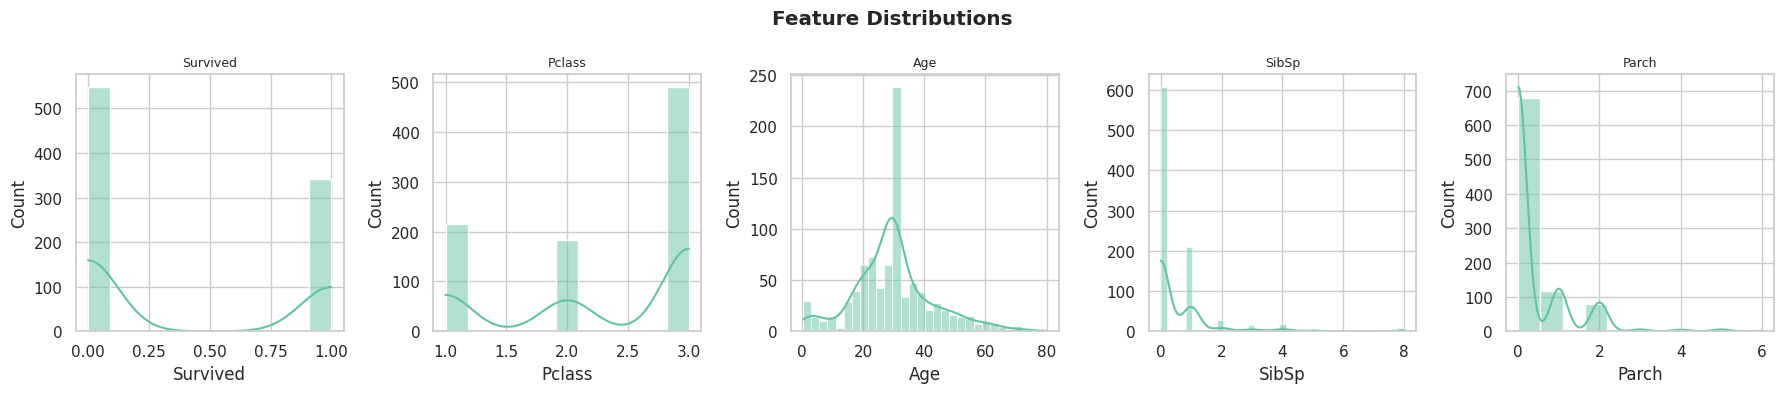

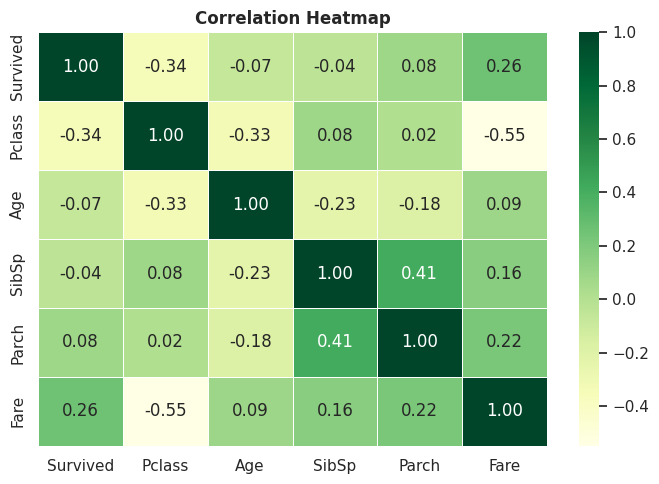

In [27]:
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col], ax=ax, kde=True)
    ax.set_title(col.split('(')[0], fontsize=9)

plt.suptitle('Feature Distributions', fontweight='bold')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='YlGn', linewidths=0.5)

plt.title('Correlation Heatmap', fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 7 | Encoding Categorical Data

In [28]:
cat_cols = ['Sex', 'Embarked', 'Cabin', 'Ticket', 'Name']

df_enc = df.copy()

# Label Encoding
le = LabelEncoder()
df_enc['Sex_LE'] = le.fit_transform(df_enc['Sex'])

df_enc.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_LE
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,B96 B98,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,B96 B98,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,B96 B98,S,1
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,B96 B98,Q,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S,1
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,B96 B98,S,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,B96 B98,S,0
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,B96 B98,C,0


In [29]:
# One-Hot Encoding
df_ohe = pd.get_dummies(df_enc, columns=cat_cols, drop_first=True)
df_ohe.head(3)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_LE,Sex_male,Embarked_Q,...,"Name_Yrois, Miss. Henriette (""Mrs Harbeck"")","Name_Zabour, Miss. Hileni","Name_Zabour, Miss. Thamine","Name_Zimmerman, Mr. Leo","Name_de Messemaeker, Mrs. Guillaume Joseph (Emma)","Name_de Mulder, Mr. Theodore","Name_de Pelsmaeker, Mr. Alfons","Name_del Carlo, Mr. Sebastiano","Name_van Billiard, Mr. Austin Blyler","Name_van Melkebeke, Mr. Philemon"
0,1,0,3,22.0,1,0,7.2500,1,True,False,...,False,False,False,False,False,False,False,False,False,False
1,2,1,1,38.0,1,0,71.2833,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,1,3,26.0,0,0,7.9250,0,False,False,...,False,False,False,False,False,False,False,False,False,False


## Cell 8 | Scaling & Normalization

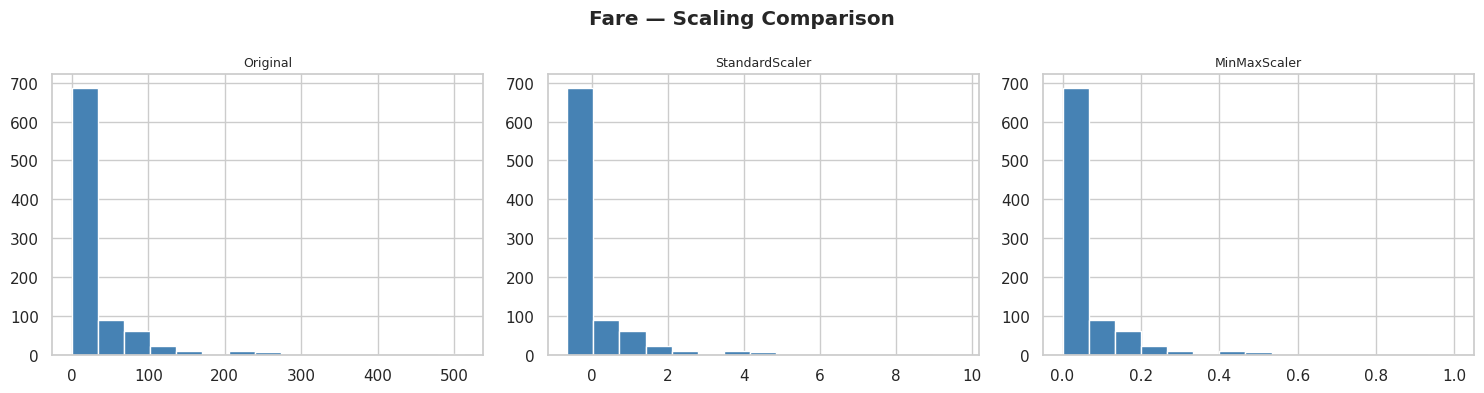

In [30]:
X_num = df[num_cols].copy()
fare_idx = num_cols.index('Fare')

scalers = {
    'Original'       : X_num['Fare'],
    'StandardScaler'  : pd.Series(StandardScaler().fit_transform(X_num)[:, fare_idx]),
    'MinMaxScaler'    : pd.Series(MinMaxScaler().fit_transform(X_num)[:, fare_idx])
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, data) in zip(axes, scalers.items()):
    ax.hist(data, bins=15, color='steelblue', edgecolor='white')
    ax.set_title(name, fontsize=9)

plt.suptitle('Fare — Scaling Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

## Cell 9 | Train-Test Split

X_train: (712, 11)  |  X_test: (179, 11)


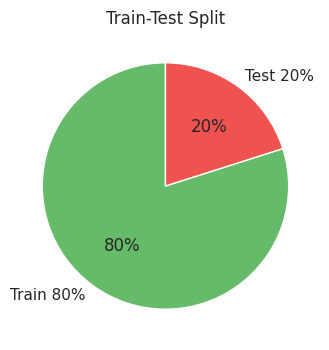

In [31]:
X = df_enc.drop(columns=['Survived', 'Sex_LE'], errors='ignore')
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

plt.figure(figsize=(4, 4))
plt.pie([len(X_train), len(X_test)], labels=['Train 80%', 'Test 20%'],
        colors=['#66BB6A','#EF5350'], autopct='%1.0f%%', startangle=90)
plt.title('Train-Test Split'); plt.show()

## Cell 10 | Activity — Full Preprocessing Pipeline

In [32]:
data = pd.read_csv('/content/train (1).csv')



# Fill missing
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df['Cabin'].fillna(df['Cabin'].mode()[0], inplace=True)


# Clean
df.drop_duplicates(inplace=True)

# Encode
df = pd.get_dummies(df, columns=['Sex','Embarked','Cabin','Ticket','Name'], drop_first=True)

# Split
X = df.drop(columns=['Survived'], errors='ignore').values
y = df['Survived'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Pipeline complete X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Pipeline complete X_train: (712, 1725)  |  X_test: (179, 1725)
